# Primera red neuronal: de Celsius a Fahrenheit

En este cuaderno vas a construir una red neuronal mínima para resolver una conversión conocida: pasar temperaturas de grados Celsius a grados Fahrenheit.

La idea no es que la red neuronal sea necesaria para este problema. La idea es usar un caso simple para observar cómo un modelo aprende una relación entre entradas y salidas.

## Objetivos de aprendizaje

Al finalizar este cuaderno, vas a poder:

- distinguir variables de entrada y variables de salida;
- construir una red neuronal con una sola capa densa;
- entrenar el modelo y leer la pérdida;
- hacer una predicción con un dato nuevo;
- comparar lo que aprendió el modelo con la fórmula real.

## Microglosario

- **Entrada**: dato que recibe el modelo. En este caso, una temperatura en Celsius.
- **Salida**: dato que queremos que el modelo prediga. En este caso, una temperatura en Fahrenheit.
- **Pérdida**: medida del error del modelo durante el entrenamiento.
- **Época**: pasada completa por los datos de entrenamiento.
- **Peso**: valor interno que el modelo ajusta para aprender la relación entre entrada y salida.

## 1. Cargar los datos

Primero cargamos una tabla con ejemplos de temperaturas en Celsius y su equivalente en Fahrenheit.

In [8]:
import pandas as pd

ruta_datos = "./datos/celsius.csv"
datos_temperatura = pd.read_csv(ruta_datos)

display(datos_temperatura.head())
print("Cantidad de filas y columnas:", datos_temperatura.shape)

,celsius,fahrenheit
0,-40,-40.0
1,-10,14.0
2,0,32.0
3,8,46.4
4,15,59.0


Cantidad de filas y columnas: (7, 2)


**Consigna de lectura:** observá las columnas. ¿Cuál representa la entrada del modelo y cuál representa la salida esperada?

## 2. Separar entrada y salida

Para entrenar un modelo supervisado necesitamos pares de ejemplos: una entrada y una respuesta correcta.

In [9]:
temperaturas_celsius = datos_temperatura["celsius"].values
temperaturas_fahrenheit = datos_temperatura["fahrenheit"].values

print("Primeras entradas en Celsius:")
print(temperaturas_celsius[:5])

print("Primeras salidas esperadas en Fahrenheit:")
print(temperaturas_fahrenheit[:5])

Primeras entradas en Celsius:
[-40 -10   0   8  15]
Primeras salidas esperadas en Fahrenheit:
[-40.   14.   32.   46.4  59. ]


**Consigna de lectura:** compará los primeros valores. ¿La relación parece lineal?

## 3. Construir el modelo

Vamos a usar una red neuronal muy pequeña. Tiene una entrada numérica y una salida numérica.

Esta arquitectura es suficiente porque el problema real también tiene una relación lineal: `fahrenheit = celsius * 1.8 + 32`.

In [10]:
import tensorflow as tf

modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1),
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_squared_error",
)

modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

**Consigna de lectura:** revisá la salida de `summary()`. ¿Cuántos parámetros ajustables tiene esta red?

## 4. Entrenar el modelo

Durante el entrenamiento, el modelo ajusta sus pesos para reducir la pérdida. Usamos muchas épocas porque el modelo es muy pequeño y el conjunto de datos también.

In [11]:
EPOCAS = 500

historial_entrenamiento = modelo.fit(
    temperaturas_celsius,
    temperaturas_fahrenheit,
    epochs=EPOCAS,
    verbose=0,
)

perdida_final = historial_entrenamiento.history["loss"][-1]
print(f"Pérdida final: {perdida_final:.4f}")

Pérdida final: 7.0972


**Consigna de lectura:** una pérdida más baja indica menor error. En este problema, ¿esperarías que el modelo pueda acercarse mucho a la fórmula real?

## 5. Visualizar la pérdida

La curva de pérdida permite ver si el entrenamiento avanzó en la dirección esperada.

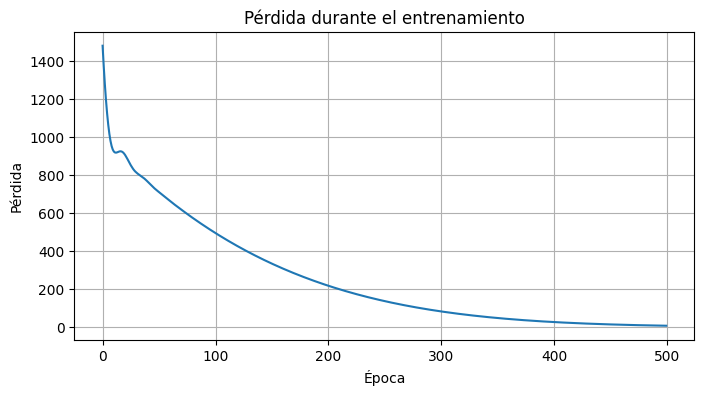

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(historial_entrenamiento.history["loss"])
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.grid(True)
plt.show()

**Consigna de lectura:** observá si la curva baja, se estabiliza o sube. ¿Qué te dice eso sobre el aprendizaje del modelo?

## 6. Hacer una predicción

Ahora usamos el modelo con un valor que puede no estar en la tabla original.

In [13]:
import numpy as np

temperatura_celsius_nueva = 12
entrada_modelo = np.array([[temperatura_celsius_nueva]])
prediccion = modelo.predict(entrada_modelo, verbose=0)
temperatura_predicha = prediccion[0][0]

print(f"Entrada: {temperatura_celsius_nueva} grados Celsius")
print(f"Predicción del modelo: {temperatura_predicha:.2f} grados Fahrenheit")

Entrada: 12 grados Celsius
Predicción del modelo: 51.17 grados Fahrenheit


**Consigna de lectura:** calculá mentalmente o con una calculadora la fórmula real. ¿Qué tan cerca quedó la predicción?

## 7. Comparar con la fórmula real

La fórmula conocida es:

`fahrenheit = celsius * 1.8 + 32`

Como el modelo tiene una sola neurona, sus pesos deberían acercarse a esos dos valores: una pendiente cercana a `1.8` y un sesgo cercano a `32`.

In [14]:
peso, sesgo = modelo.layers[0].get_weights()

print("Peso aprendido:", peso[0][0])
print("Sesgo aprendido:", sesgo[0])

Peso aprendido: 1.8228629
Sesgo aprendido: 29.300545


**Consigna de lectura:** compará el peso y el sesgo con la fórmula real. ¿Qué parte de la fórmula representa cada uno?

## Cierre

En este ejemplo, la red aprendió una relación matemática simple a partir de datos. Este mismo principio se mantiene en problemas más complejos: el modelo recibe ejemplos, ajusta sus parámetros y reduce el error.

En los próximos cuadernos vamos a pasar de datos numéricos simples a imágenes, donde la entrada ya no será un solo número sino una matriz de píxeles.